In [1]:
import os
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
from utils8 import AudioCNN
from utils8.data import AudioDataset, get_dataloader

# Get Data
path = os.path.join('Data', 'Digits')
classes = ['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine']
dataset = AudioDataset(path, classes)

# Data Split and Subsets
idx = list(range(len(dataset)))
labels = dataset.labels
train_val_idx, test_idx = train_test_split(idx, test_size=0.2, stratify=labels, random_state=42)

train_val_set = Subset(dataset, train_val_idx)
test_set = Subset(dataset, test_idx)

## Getting optuna parameters

In [3]:
import pandas as pd

studies = sorted(os.listdir('optuna_results'))

print('Available studies: ')
for s in studies:
    s = s.replace('(', '_')
    s = s.replace(')', '_')
    parsed_s = s.split('_')
    print(f'{parsed_s[1]}/{parsed_s[2]}/{parsed_s[3]} - {parsed_s[4]}')

last_study_path = os.path.join('optuna_results', studies[-1])
last_study = pd.read_csv(last_study_path)


last_study

Available studies: 
20/05/2026 - 12:08


,number,value,datetime_start,datetime_complete,duration,params_dropout_rate,params_lr,params_patience,params_weight_decay,state
0,20,0.500792,2026-05-20 07:27:05.804786,2026-05-20 08:21:50.843694,0 days 00:54:45.038908,0.008297,0.001607,5,0.000143,COMPLETE
1,21,0.514238,2026-05-20 08:21:50.846912,2026-05-20 09:16:40.114468,0 days 00:54:49.267556,0.010482,0.001545,5,0.000138,COMPLETE
2,24,0.551658,2026-05-20 11:07:16.834302,2026-05-20 12:08:31.918352,0 days 01:01:15.084050,0.014147,0.001752,5,0.000037,COMPLETE
3,16,0.648541,2026-05-20 03:45:57.568698,2026-05-20 04:41:27.957551,0 days 00:55:30.388853,0.004735,0.000451,3,0.000044,COMPLETE
4,10,0.704174,2026-05-19 21:23:32.511006,2026-05-19 22:22:24.762476,0 days 00:58:52.251470,0.395976,0.001647,2,0.000012,COMPLETE
5,19,0.708246,2026-05-20 06:31:32.789569,2026-05-20 07:27:05.804116,0 days 00:55:33.014547,0.001090,0.000297,3,0.000029,COMPLETE
6,17,0.758230,2026-05-20 04:41:27.958938,2026-05-20 05:36:38.277407,0 days 00:55:10.318469,0.002047,0.000220,3,0.000058,COMPLETE
7,11,0.832159,2026-05-19 22:22:24.763269,2026-05-19 23:51:49.931434,0 days 01:29:25.168165,0.433315,0.000828,2,0.000016,COMPLETE
8,22,0.853123,2026-05-20 09:16:40.121755,2026-05-20 10:11:43.974543,0 days 00:55:03.852788,0.009083,0.000138,5,0.000135,COMPLETE
9,7,1.004616,2026-05-19 18:20:56.262730,2026-05-19 19:28:02.652269,0 days 01:07:06.389539,0.228612,0.000280,2,0.001309,COMPLETE


In [21]:
study = last_study.iloc[0].to_dict()

network_col = ["params_dropout_rate", "params_lr", "params_patience", "params_weight_decay"]
best_params = {}
for col in network_col:
    best_params[col.removeprefix('params_')] = study[col]

best_params

{'dropout_rate': 0.0082966517228649,
 'lr': 0.0016068082173041,
 'patience': 5,
 'weight_decay': 0.0001426599145501}

# Training

In [22]:
import os
from sklearn.model_selection import KFold
from torch.utils.tensorboard import SummaryWriter
from torch import nn,optim
from utils8.dir_managment import clean_dir
from utils8.AudioCNN import AudioCNN
from utils8.training import train_one_fold, get_train_loaders, save_model_dict, save_target_labels


model_name = 'model_2'

log_dir = os.path.join('runs', 'training', model_name)
clean_dir(log_dir)
os.makedirs(log_dir, exist_ok=True)
writer = SummaryWriter(log_dir=log_dir)

save_model_dir = os.path.join('Models', model_name)
clean_dir(save_model_dir)
os.makedirs(save_model_dir, exist_ok=True)

model_params = {'dropout_rate': best_params['dropout_rate'], 'num_classes': 10}
save_model_dict(model_params, save_model_dir)
save_target_labels(classes, save_model_dir)

N_EPOCHS = 50
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(kf.split(train_val_set)):
    print(f'\n ===================== Training Fold {fold}  ===================== \n')
    # Loaders
    train_loader, val_loader = get_train_loaders(train_val_set, train_idx,val_idx , batch_size=32)

    # Model, Optimizer, Criterion
    criterion = nn.CrossEntropyLoss()
    model =  AudioCNN(dropout_rate=best_params['dropout_rate'])
    optimizer = optim.Adam(model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=best_params['patience'])

    # Fold Training
    loss = train_one_fold(fold, model, train_loader, val_loader, optimizer, scheduler, criterion, n_epochs=N_EPOCHS, write_model_dir=save_model_dir, writer=writer)




Model dict saved in Models/model_2/model_dict.json
Labels dict saved in Models/model_2/data_labels.json

 ===================== Training Fold 0  ===================== 

Saved new best model to Models/model_2/fold_0.pth, with new best_val_loss=1.519362677026678
Saved new best model to Models/model_2/fold_0.pth, with new best_val_loss=1.2161214605525688
Saved new best model to Models/model_2/fold_0.pth, with new best_val_loss=0.9817399410185991
Saved new best model to Models/model_2/fold_0.pth, with new best_val_loss=0.7004405640893512
Saved new best model to Models/model_2/fold_0.pth, with new best_val_loss=0.6732029147722103
Saved new best model to Models/model_2/fold_0.pth, with new best_val_loss=0.5637495870943423
Saved new best model to Models/model_2/fold_0.pth, with new best_val_loss=0.5149880599368502
Saved new best model to Models/model_2/fold_0.pth, with new best_val_loss=0.4387626803859516
Saved new best model to Models/model_2/fold_0.pth, with new best_val_loss=0.410062632764

In [ ]:
# tensorboard --logdir Lab8/runs/training/model_2

# Model Evaluation

In [23]:
import os
from utils8.Predictor import Predictor

model_path = os.path.join('Models', 'model_2')
predictor_obj = Predictor(model_path)

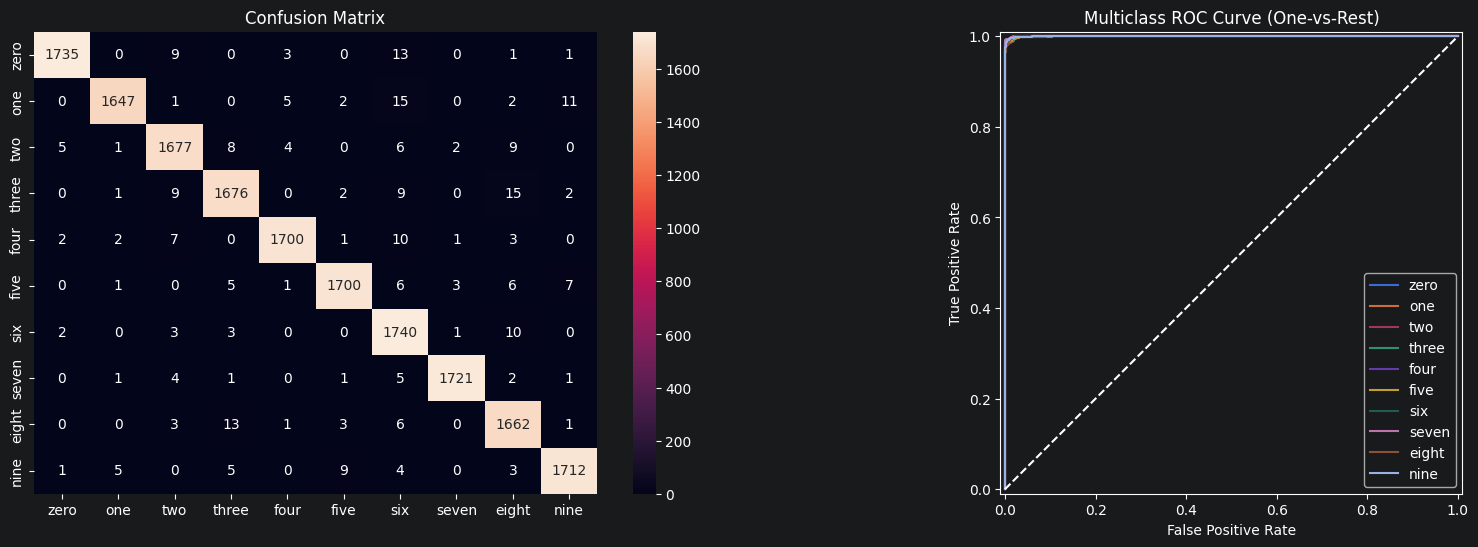

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1762
           1       0.99      0.98      0.99      1683
           2       0.98      0.98      0.98      1712
           3       0.98      0.98      0.98      1714
           4       0.99      0.98      0.99      1726
           5       0.99      0.98      0.99      1729
           6       0.96      0.99      0.97      1759
           7       1.00      0.99      0.99      1736
           8       0.97      0.98      0.98      1689
           9       0.99      0.98      0.99      1739

    accuracy                           0.98     17249
   macro avg       0.98      0.98      0.98     17249
weighted avg       0.98      0.98      0.98     17249



In [24]:
# Train data Classification report
predictor_obj.metric_report(data=Subset(dataset, train_val_idx))


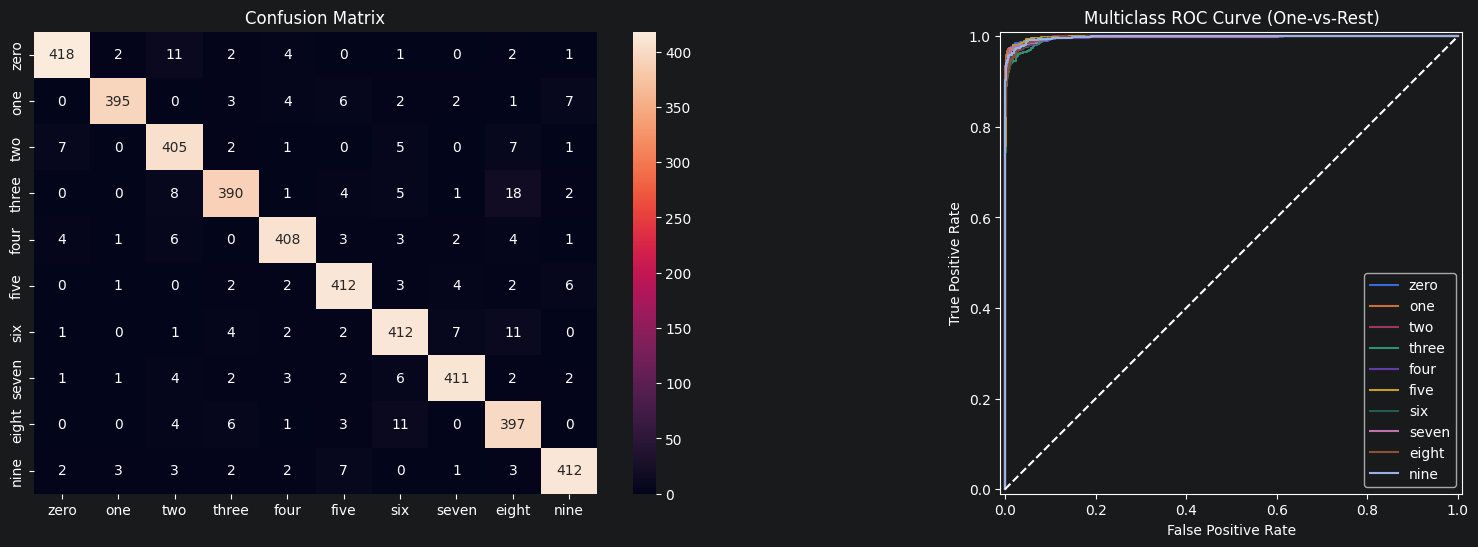

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       441
           1       0.98      0.94      0.96       420
           2       0.92      0.95      0.93       428
           3       0.94      0.91      0.93       429
           4       0.95      0.94      0.95       432
           5       0.94      0.95      0.95       432
           6       0.92      0.94      0.93       440
           7       0.96      0.95      0.95       434
           8       0.89      0.94      0.91       422
           9       0.95      0.95      0.95       435

    accuracy                           0.94      4313
   macro avg       0.94      0.94      0.94      4313
weighted avg       0.94      0.94      0.94      4313



In [25]:
# Test data Classification report
predictor_obj.metric_report(data=Subset(dataset, test_idx))